# Lid-Driven Cavity with XLB

Welcome! This notebook walks you through simulating one of the most classic problems in computational fluid dynamics: the **lid-driven cavity**. We'll use [XLB](https://github.com/Autodesk/XLB), a lattice Boltzmann library, and explain each step along the way so you understand not just *what* the code does, but *why*.

**The problem, in plain terms:** imagine a square box filled with fluid. The lid on top slides sideways at a constant speed, dragging the fluid underneath it along. The other three walls don't move. Friction between the moving lid and the fluid — and between the fluid and the stationary walls — sets up a swirling recirculation pattern inside the box. For instance, at Reynolds number = 1000, that swirl settles into a steady pattern with one large vortex in the center and smaller counter-rotating vortices tucked into the corners.

**What we'll do, step by step:**

1. Set up the library (choose the lattice model, backend, and numerical precision)
2. Build the computational grid
3. Translate physical parameters (Reynolds number, viscosity) into the numbers the lattice Boltzmann method actually uses
4. Tell the solver where the walls and the moving lid are
5. Assemble a "stepper" — the object that advances the simulation by one time step
6. Allocate the arrays that hold the simulation state
7. Run the simulation until the flow stops changing
8. Look at the results, and compare them against a well-known published benchmark

## Prerequisites

Install XLB. We'll use the **JAX backend**, which is the easiest one to inspect and debug interactively from a notebook (you can print an array, plot it, poke at it — no special handling needed). XLB also supports Warp (great for a single GPU) and Neon (for multi-GPU or multi-resolution setups), and the same code you see here works with those too, with only minor changes.

In [18]:
import json
import os
from pathlib import Path

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import xlb
import xlb.velocity_set
from xlb.compute_backend import ComputeBackend
from xlb.grid import grid_factory
from xlb.operator.boundary_condition import EquilibriumBC, HalfwayBounceBackBC
from xlb.operator.macroscopic import Macroscopic
from xlb.operator.stepper import IncompressibleNavierStokesStepper
from xlb.precision_policy import PrecisionPolicy

# Directory for saved figures (no VTK output in this notebook)
FIG_DIR = Path("figures/lid_driven_cavity_2d")
FIG_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({"figure.figsize": (6, 5), "image.cmap": "RdYlBu_r"})

---
## Step 1 — Simulation parameters

Before we touch any solver code, we need to decide on the **discretization** (how finely we chop up space) and the **physics** (how viscous the fluid is, how fast the lid moves).

| Parameter | Role |
|-----------|------|
| `grid_shape` | Number of lattice nodes in x and y — how fine the grid is |
| `compute_backend` | JAX, Warp, or Neon — which engine actually runs the math |
| `precision_policy` | Whether numbers are stored/computed in single or double precision |
| `velocity_set` | The lattice model — **D2Q9** means 9 discrete velocity directions in 2D |
| `Re`, `prescribed_vel` | Reynolds number and lid speed — together they determine the fluid's viscosity |
| `omega` | The relaxation rate used internally by the lattice Boltzmann collision step; it's derived from viscosity |

`Re` can be set to any value the simulation runs stably at, but the benchmark comparison at the end of this notebook only has reference data for `Re` in {1000, 2500, 5000, 7500, 10000, 12500, 20000, 25000, 30000} — the classic Ghia, Ghia & Shin (1982) cases. Pick one of those if you want that final comparison to work; otherwise the notebook runs fine but skips straight to "no reference data for this Re.

**Note**: as Re increases, the flow becomes more turbulent and harder to resolve. You may need to increase `grid_shape` to get a stable solution at higher Re.


In [2]:
# --- corresponds to LidDrivenCavity2D.__init__ arguments ---
grid_shape = (128, 128)
compute_backend = ComputeBackend.JAX
precision_policy = PrecisionPolicy.FP64FP64

velocity_set = xlb.velocity_set.D2Q9(
    precision_policy=precision_policy,
    compute_backend=compute_backend,
)

Re = 1000.0
prescribed_vel = 0.04  # lid speed in lattice units
clength = grid_shape[0] - 1  # cavity length (between wall nodes)
visc = prescribed_vel * clength / Re
omega = 1.0 / (3.0 * visc + 0.5)

print(f"Grid:          {grid_shape[0]} x {grid_shape[1]}")
print(f"Velocity set:  D2Q9 ({velocity_set.q} populations per node)")
print(f"Re:            {Re}")
print(f"Lid speed:     {prescribed_vel}")
print(f"Viscosity nu:  {visc:.6e}")
print(f"Relaxation omega: {omega:.6f}")

Grid:          128 x 128
Velocity set:  D2Q9 (9 populations per node)
Re:            1000.0
Lid speed:     0.04
Viscosity nu:  5.080000e-03
Relaxation omega: 1.940843


---
## Step 2 — Initialize XLB (`xlb.init`)

Before we create any grid or operator, we call `xlb.init(...)` once. Think of it as telling the library "here's what I'll be working with by default" — the lattice model, the backend, and the numerical precision. Any operator we build afterward will fall back to these defaults unless we explicitly override them.

Every XLB script or notebook should call this once at startup, before anything else.

In [3]:
xlb.init(
    velocity_set=velocity_set,
    default_backend=compute_backend,
    default_precision_policy=precision_policy,
)

No GPU support is available; CPU fallback will be used.


---
## Step 3 — Create the grid (`grid_factory`)

The **grid** is simply the container that holds all of our field arrays and knows the shape of the domain. It also gives us convenient helpers, like `bounding_box_indices()`, to find where the boundary nodes are without having to compute them by hand.

On the JAX backend, population arrays (the core data structure of the lattice Boltzmann method) will have shape `(q, nx, ny)` — one 2D slice per lattice direction.

In [4]:
grid = grid_factory(grid_shape, compute_backend=compute_backend)
print(f"Grid type: {type(grid).__name__}")
print(f"Shape:     {grid.shape}")

Grid type: JaxGrid
Shape:     (128, 128)


---
## Step 4 — Boundary indices (`define_boundary_indices`)

In XLB, boundary conditions aren't described with coordinates like "x = 0" — they're described as **lists of grid indices**. So our first job is to figure out exactly which grid nodes belong to the lid and which belong to the walls.

- **Lid (top):** the interior of the top edge. We'll apply `EquilibriumBC` here, which pins the density to ρ = 1 and the velocity to **u = (U_lid, 0)** — i.e., it forces the fluid at that boundary to move exactly at the lid's speed.
- **Walls (bottom, left, right):** we'll apply `HalfwayBounceBackBC`, which enforces the no-slip condition (fluid velocity is zero right at a stationary wall).

One subtlety: we use `bounding_box_indices(remove_edges=True)` for the lid so that the two top corners are excluded from it and treated as walls instead. Without this, a corner node would be claimed by both the lid and a wall, which doesn't make physical sense — a stationary corner can't also be moving with the lid.

In [5]:
def define_boundary_indices(grid, velocity_set):
    """Same logic as LidDrivenCavity2D.define_boundary_indices."""
    box = grid.bounding_box_indices()
    box_no_edge = grid.bounding_box_indices(remove_edges=True)
    lid = box_no_edge["top"]
    walls = [box["bottom"][i] + box["left"][i] + box["right"][i] for i in range(velocity_set.d)]
    walls = np.unique(np.array(walls), axis=-1).tolist()
    return lid, walls


lid_indices, wall_indices = define_boundary_indices(grid, velocity_set)
print(f"Lid nodes:  {len(lid_indices[0])} points along the top edge")
print(f"Wall nodes: {len(wall_indices[0])} points on bottom/left/right")

Lid nodes:  126 points along the top edge
Wall nodes: 382 points on bottom/left/right


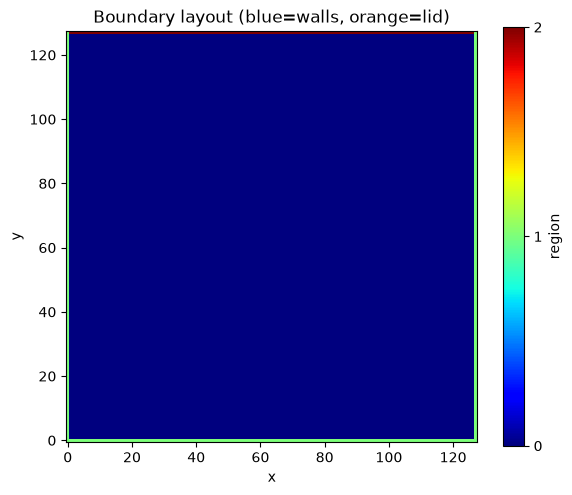

In [22]:
# Visualize where BCs are applied
bc_map = np.zeros(grid_shape, dtype=int)  # 0 = interior, 1 = wall, 2 = lid
for i in range(len(wall_indices[0])):
    bc_map[wall_indices[0][i], wall_indices[1][i]] = 1
for i in range(len(lid_indices[0])):
    bc_map[lid_indices[0][i], lid_indices[1][i]] = 2

fig, ax = plt.subplots()
im = ax.imshow(bc_map.T, origin="lower", cmap="jet", vmin=0, vmax=2)
ax.set_title("Boundary layout (blue=walls, orange=lid)")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(im, ax=ax, ticks=[0, 1, 2], label="region")
fig.tight_layout()
fig.savefig(FIG_DIR / "00_boundary_layout.png", dpi=150)
plt.show()

---
## Step 5 — Boundary condition objects (`setup_boundary_conditions`)

Now we turn those index lists into actual boundary-condition **operators** — objects the solver will call at every time step.

| BC | When applied | Effect |
|----|--------------|--------|
| `HalfwayBounceBackBC` | After streaming | No-slip wall: incoming populations get reflected back the way they came |
| `EquilibriumBC` | After streaming | Overwrites populations with the equilibrium distribution for the prescribed ρ and **u** — this is how we force the lid's velocity |

We collect both into a single list. The stepper will loop over this list and apply each one, every single time step.

In [7]:
bc_walls = HalfwayBounceBackBC(indices=wall_indices)
bc_top = EquilibriumBC(rho=1.0, u=(prescribed_vel, 0.0), indices=lid_indices)
boundary_conditions = [bc_walls, bc_top]

print(boundary_conditions)

registered bc HalfwayBounceBackBC_298317822 with id 1
WARNING! Assuming no-slip condition for BC type = HalfwayBounceBackBC!
registered bc EquilibriumBC_298297156 with id 2
[HalfwayBounceBackBC(), EquilibriumBC()]


---
## Step 6 — Build the stepper (`setup_stepper`)

Here's where everything comes together. `IncompressibleNavierStokesStepper` bundles all the individual lattice Boltzmann operations into one object you can just call once per time step:

```
pull scheme (default):
  Stream(f_0)
  → post-stream BCs (EquilibriumBC, BounceBack, …)
  → Macroscopic: recover rho, u
  → QuadraticEquilibrium: build f_eq
  → BGK collision
  → post-collision BCs + auxiliary assembly
  → write f_1
```

If you're new to lattice Boltzmann methods: "streaming" moves populations to neighboring nodes, and "collision" relaxes them toward local equilibrium. Repeating these two steps, over and over, is what produces fluid-like behavior — no need to solve the Navier-Stokes equations directly.

You can also choose a different collision model at construction time (`"BGK"`, `"KBC"`, `"SmagorinskyLESBGK"`) — we'll stick with the simplest and most common one, standard **BGK**.

In [8]:
stepper = IncompressibleNavierStokesStepper(
    grid=grid,
    boundary_conditions=boundary_conditions,
    collision_type="BGK",
)
print(f"Streaming scheme: {stepper.streaming_scheme}")
print(f"Collision:        {type(stepper.collision).__name__}")

Streaming scheme: pull
Collision:        BGK


---
## Step 7 — Prepare fields (`prepare_fields`)

`stepper.prepare_fields()` allocates everything the time loop needs:

| Field | Shape (2D, JAX) | Purpose |
|-------|-----------------|--------|
| `f_0` | `(q, nx, ny)` | The current population distributions — this is the actual simulation state |
| `f_1` | `(q, nx, ny)` | A second buffer to write the next step into |
| `bc_mask` | `(1, nx, ny)` | Marks which boundary condition (if any) applies at each node |
| `missing_mask` | `(q, nx, ny)` | Marks which incoming directions are "missing" at boundary nodes (blocked by a wall) |

Everything starts out at **uniform equilibrium**: density ρ = 1 everywhere, velocity **u** = 0 everywhere. That's just "fluid at rest" — the natural starting point before the lid starts moving it.

In [9]:
f_0, f_1, bc_mask, missing_mask = stepper.prepare_fields()

print(f"f_0 shape:          {f_0.shape}")
print(f"f_1 shape:          {f_1.shape}")
print(f"bc_mask shape:      {bc_mask.shape}, dtype={bc_mask.dtype}")
print(f"missing_mask shape: {missing_mask.shape}, dtype={missing_mask.dtype}")
print(f"Sum of f_0 (should ≈ rho * nx * ny): {float(jnp.sum(f_0)):.1f}")

Warp 1.16.0 initialized:
   CUDA not enabled in this build
   Devices:
     "cpu"      : "arm"
   Kernel cache:
     /Users/rivas/Library/Caches/warp/1.16.0
f_0 shape:          (9, 128, 128)
f_1 shape:          (9, 128, 128)
bc_mask shape:      (1, 128, 128), dtype=uint8
missing_mask shape: (9, 128, 128), dtype=bool
Sum of f_0 (should ≈ rho * nx * ny): 16384.0


The following functions are used to extract the velocity and plot the velocity field.

In [10]:
def recover_macroscopic(f, velocity_set, precision_policy):
    """Recover rho and u from populations using the Macroscopic operator."""
    macro = Macroscopic(
        compute_backend=ComputeBackend.JAX,
        precision_policy=precision_policy,
        velocity_set=velocity_set,
    )
    return macro(f)


def plot_velocity_magnitude(f, title, save_path=None):
    """Recover velocity and plot |u| (interior nodes only)."""
    _, u = recover_macroscopic(f, velocity_set, precision_policy)
    u = u[:, 1:-1, 1:-1]
    u_mag = jnp.sqrt(u[0] ** 2 + u[1] ** 2)

    fig, ax = plt.subplots()
    im = ax.imshow(u_mag.T, origin="lower")

    kin_energy = jnp.mean(u_mag**2)
    ax.set_title(title + f"\nKinetic Energy Average: {float(kin_energy):.6e}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(im, ax=ax, label="|u|")
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150)
    plt.show()

    return u_mag

---
## Step 8 — The time loop (`run`)

Now the fun part: actually running the simulation. Each step is remarkably short:

```python
f_0, f_1 = stepper(f_0, f_1, bc_mask, missing_mask, omega, i)
f_0, f_1 = f_1, f_0  # swap buffers
```

That's it — call the stepper, swap the buffers, repeat. `omega` is the relaxation rate we computed back in Step 1 (constant here, but it could vary in space for a spatially-varying viscosity). The step index `i` is passed along too, in case a boundary condition depends on time — not needed for our steady lid problem, but the stepper always expects it.

The one question we still need to answer: **how many steps is enough?** Rather than guessing a fixed number, we advance in blocks of `check_every` steps and, after each block, measure how much the velocity field changed compared to the previous block. Once that change drops below a small tolerance `tol`, we consider the flow to have reached steady state and stop (or we give up after `max_steps`, just in case). Along the way, we also save a snapshot of the velocity field so we can watch the flow develop.

> **Note**: the num of steps are large to allow the flow to reach steady state. For a higher Reynolds number, the flow takes longer to reach steady state or may not reach steady state at all. You may need to increase `grid_shape` to get a stable solution at higher Re.

In [ ]:
from IPython.display import clear_output as clc

check_every = 10_000
max_steps = 400_000
tol = 1e-4

_, u_prev = recover_macroscopic(f_0, velocity_set, precision_policy)
u_prev = np.asarray(u_prev)

num_steps = 0
rel_change = np.inf
while num_steps < max_steps:
    for _ in range(check_every):
        f_0, f_1 = stepper(f_0, f_1, bc_mask, missing_mask, omega, num_steps)
        f_0, f_1 = f_1, f_0
        num_steps += 1
    plot_velocity_magnitude(
        f_0,
        f"Velocity step {num_steps}",
        FIG_DIR / f"velocity_step_{num_steps:06d}.png",
    )

    _, u_curr = recover_macroscopic(f_0, velocity_set, precision_policy)
    u_curr = np.asarray(u_curr)
    rel_change = np.linalg.norm(u_curr - u_prev) / (np.linalg.norm(u_curr) + 1e-14)
    u_prev = u_curr

    print(f"Step {num_steps:6d}: relative change = {rel_change:.3e}")
    clc(wait=True)
    plt.close()

    if rel_change < tol:
        break

print(f"Stopped after {num_steps} steps (relative change = {rel_change:.3e})")

Stopped after 240000 steps (relative change = 8.899e-05)


---
## Step 9 — Post-processing (`post_process`)

Now that the flow has settled, let's look at what actually happened.

We'll use `Macroscopic` to convert the raw lattice populations back into density ρ and velocity **u** — the quantities you'd actually plot or report. We also trim off the outermost layer of boundary nodes before plotting, since those are constrained by boundary conditions rather than being "real" interior flow.

> **Note:** if you switch to the Warp backend instead of JAX, arrays come with an extra trailing dimension. You'd need `warp_array_to_jax(f_0)[..., 0]` to squeeze it out before running the same post-processing code.

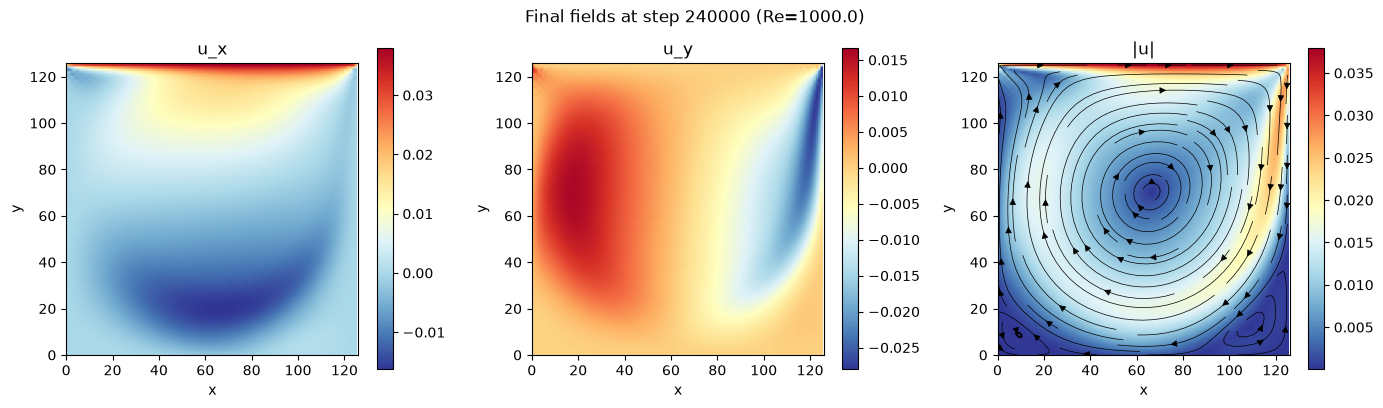

Max |u|: 0.0379
Figures saved under: /Users/rivas/Github/XLB/examples/tutorials/figures/lid_driven_cavity_2d


In [ ]:
rho, u = recover_macroscopic(f_0, velocity_set, precision_policy)

# Remove boundary nodes (same as the script)
rho_int = rho[:, 1:-1, 1:-1]
u_int = u[:, 1:-1, 1:-1]
u_mag = jnp.sqrt(u_int[0] ** 2 + u_int[1] ** 2)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, data, label in zip(
    axes,
    [u_int[0], u_int[1], u_mag],
    ["u_x", "u_y", "|u|"],
):
    im = ax.imshow(data.T, origin="lower")
    ax.set_title(label)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(im, ax=ax)
    ax.set_xlim(0, grid_shape[0] - 2)
    ax.set_ylim(0, grid_shape[1] - 2)

# Overlay streamlines on the |u| panel to show the recirculation pattern
nx_int, ny_int = u_int.shape[1], u_int.shape[2]
axes[2].streamplot(
    np.arange(nx_int),
    np.arange(ny_int),
    np.asarray(u_int[0]).T,
    np.asarray(u_int[1]).T,
    color="k",
    density=1.0,
    linewidth=0.5,
)

fig.suptitle(f"Final fields at step {num_steps} (Re={Re})")
fig.tight_layout()
fig.savefig(FIG_DIR / "final_velocity_components.png", dpi=150)
plt.show()

print(f"Max |u|: {float(jnp.max(u_mag)):.4f}")
print(f"Figures saved under: {FIG_DIR.resolve()}")

---
## Comparing against a published benchmark

A simulation is only useful if you can trust it, so let's check our results against real published data. Ghia, Ghia & Shin (1982) is the classic reference for this exact problem — they tabulated velocity profiles along the vertical and horizontal centerlines of the cavity for several Reynolds numbers. This notebook ships pre-converted reference data for `Re` in {1000, 2500, 5000, 7500, 10000, 12500, 20000, 25000, 30000}; if you ran with a different `Re`, the cells below will tell you and skip the comparison rather than failing.

Rather than typing that table in by hand, we load it from a JSON file extracted directly from the original tables (see this [Github repository](https://github.com/Steriva/extract-ghia)). If the velocity profile our simulation produces lines up with these points, that's strong evidence our setup — boundary conditions, grid resolution, viscosity — is correct.


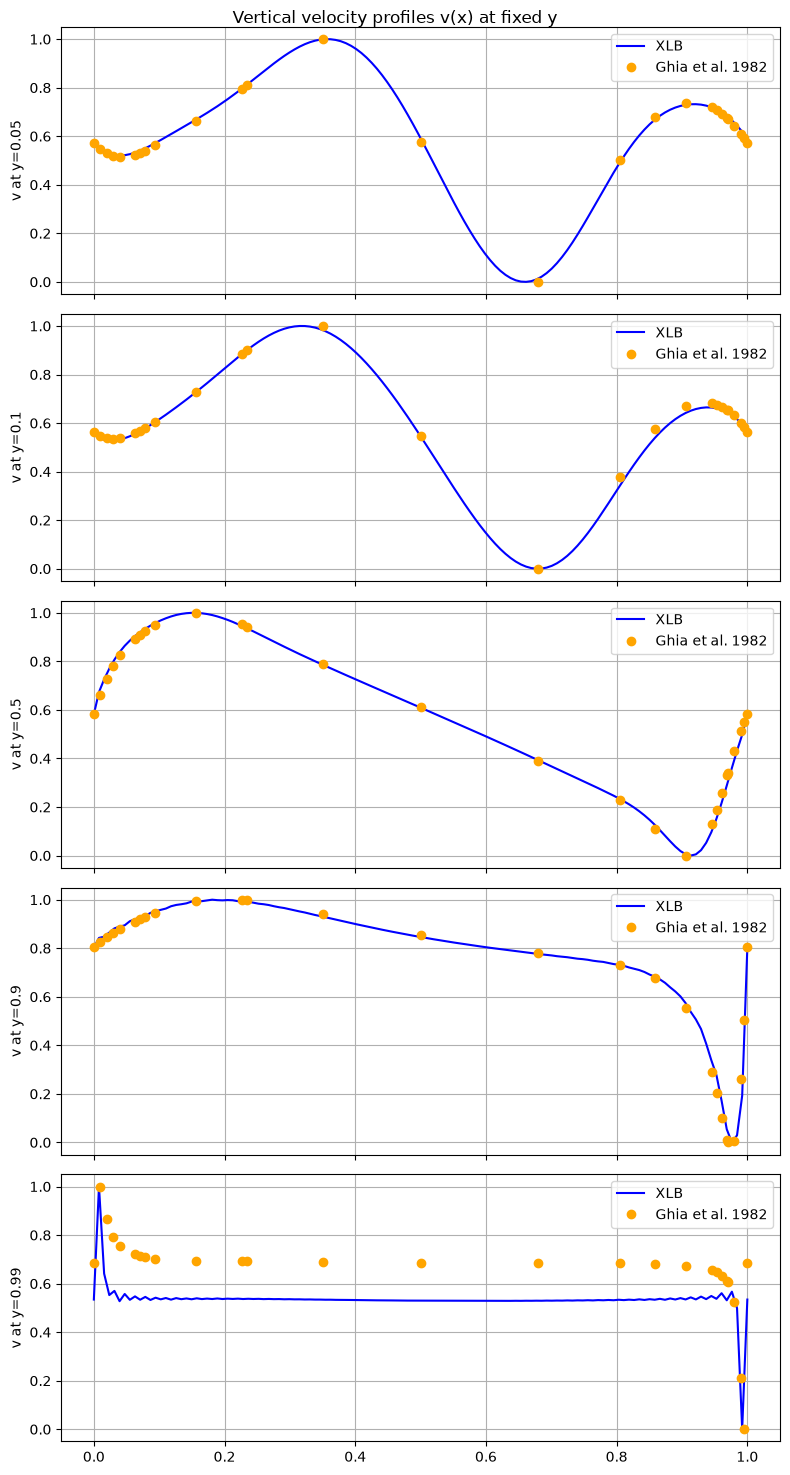

In [13]:
# Ghia benchmark data, converted to JSON by extract-ghia (see markdown cell above)
BENCH_DIR = Path("../cfd/data/cavity-ghia")
AVAILABLE_RE = sorted(int(p.stem.removeprefix("ghia_Re_")) for p in BENCH_DIR.glob("ghia_Re_*.json"))

bench_path = BENCH_DIR / f"ghia_Re_{int(Re)}.json"
if bench_path.exists():
    with open(bench_path) as f:
        ghia = json.load(f)
else:
    ghia = None
    print(f"No Ghia reference data for Re={Re:g}; available values are {AVAILABLE_RE}.")
    print("Skipping the benchmark comparison below.")

x = np.linspace(0, 1, grid_shape[0])  # interior nodes only
y = np.linspace(0, 1, grid_shape[1])  # interior nodes only

ux = u_int[0]
uy = u_int[1]

if ghia is not None:
    # v(x, y) at 5 fixed y locations (vertical_velocity table), Ghia-style "v at y=..."
    vert_vel = ghia["vertical_velocity"]
    ycols = [0.05, 0.10, 0.50, 0.90, 0.99]
    vcols = ["v_y0.05", "v_y0.10", "v_y0.50", "v_y0.90", "v_y0.99"]

    fig, axs = plt.subplots(len(ycols), 1, figsize=(8, 3 * len(ycols)), sharey=True, sharex=True)

    for ii, (_y, col) in enumerate(zip(ycols, vcols)):
        bench_x = np.array(vert_vel["x"])
        bench_uy = np.array(vert_vel[col])

        # Find the index of the closest y value in the grid
        y_idx = np.argmin(np.abs(y[1:-1] - _y))
        computed_uy = np.concatenate([[0], uy[:, y_idx], [0]])  # add zero at boundaries for plotting

        ax = axs[ii]
        ax.plot(x, (computed_uy - min(computed_uy)) / (max(computed_uy) - min(computed_uy)), label="XLB", color="blue")
        ax.plot(bench_x, (bench_uy - min(bench_uy)) / (max(bench_uy) - min(bench_uy)), "o", label="Ghia et al. 1982", color="orange")
        ax.set_ylabel(f"v at y={_y}")
        ax.legend()
        ax.grid()
    fig.suptitle("Vertical velocity profiles v(x) at fixed y")
    fig.tight_layout()

The JSON file also has a `horizontal_velocity` table — the mirror image of the one above, giving u(y) at 5 fixed x locations — and centerline tables (`centerline_u` = u along x=0.5, `centerline_v` = v along y=0.5). Let's check those too.

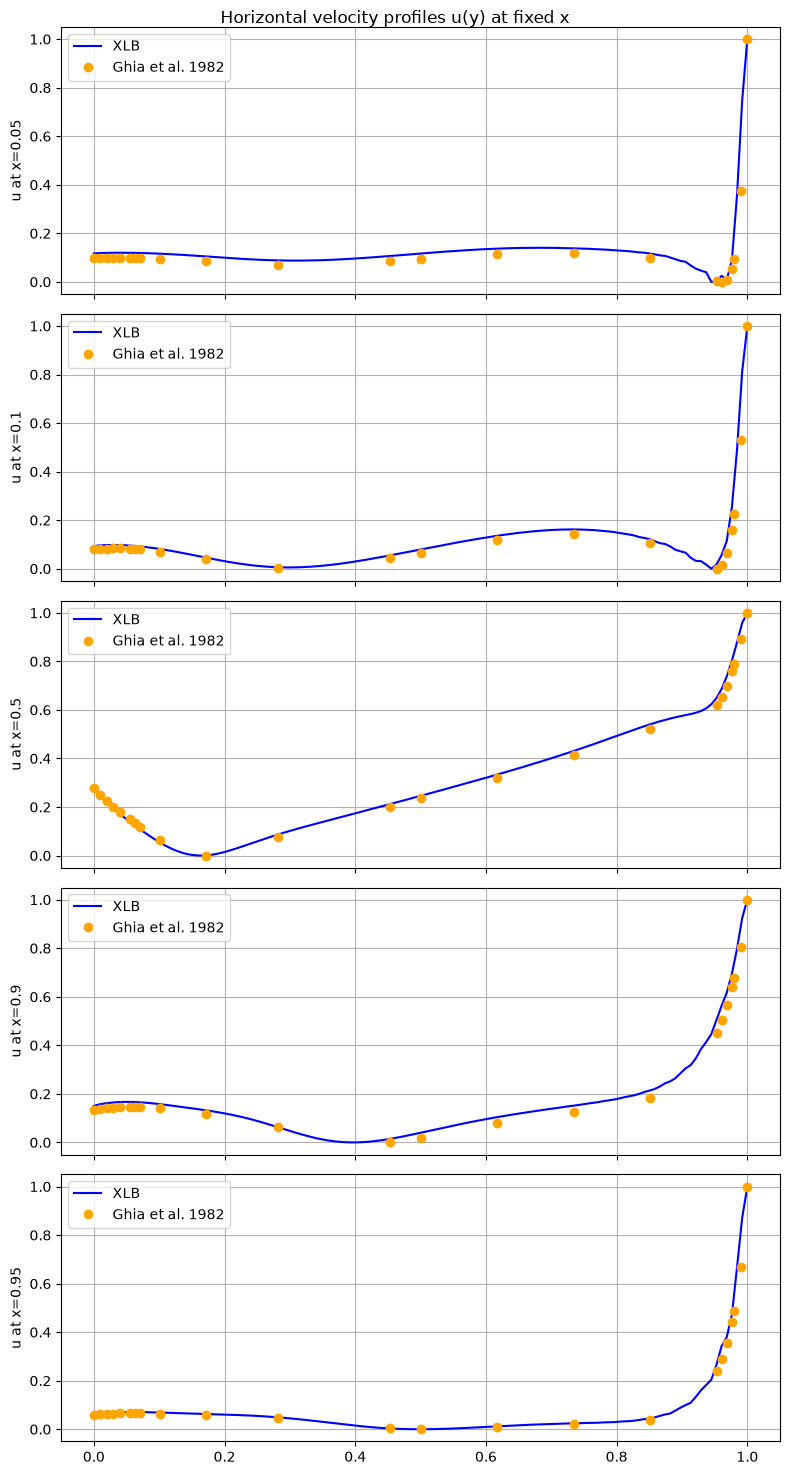

In [14]:
if ghia is not None:
    # u(x, y) at 5 fixed x locations (horizontal_velocity table), Ghia-style "u at x=..."
    horiz_vel = ghia["horizontal_velocity"]
    xcols = [0.05, 0.10, 0.50, 0.90, 0.95]
    ucols = ["u_x0.05", "u_x0.10", "u_x0.50", "u_x0.90", "u_x0.95"]

    fig, axs = plt.subplots(len(xcols), 1, figsize=(8, 3 * len(xcols)), sharey=True, sharex=True)

    for ii, (_x, col) in enumerate(zip(xcols, ucols)):
        bench_y = np.array(horiz_vel["y"])
        bench_ux = np.array(horiz_vel[col])

        # Find the index of the closest x value in the grid
        x_idx = np.argmin(np.abs(x[1:-1] - _x))
        computed_ux = np.concatenate([[0], ux[x_idx, :], [prescribed_vel]])  # wall at y=0, lid at y=1

        ax = axs[ii]
        ax.plot(y, (computed_ux - min(computed_ux)) / (max(computed_ux) - min(computed_ux)), label="XLB", color="blue")
        ax.plot(bench_y, (bench_ux - min(bench_ux)) / (max(bench_ux) - min(bench_ux)), "o", label="Ghia et al. 1982", color="orange")
        ax.set_ylabel(f"u at x={_x}")
        ax.legend()
        ax.grid()
    fig.suptitle("Horizontal velocity profiles u(y) at fixed x")
    fig.tight_layout()

Finally, the classic Ghia et al. figure: velocity along the two centerlines of the cavity — u(x=0.5, y) and v(x, y=0.5). The benchmark tables report velocity normalized by the lid speed U_lid, so we divide our computed velocities by `prescribed_vel` to put them on the same scale (unlike the profile plots above, this is a physical rescaling, not a min-max normalization).

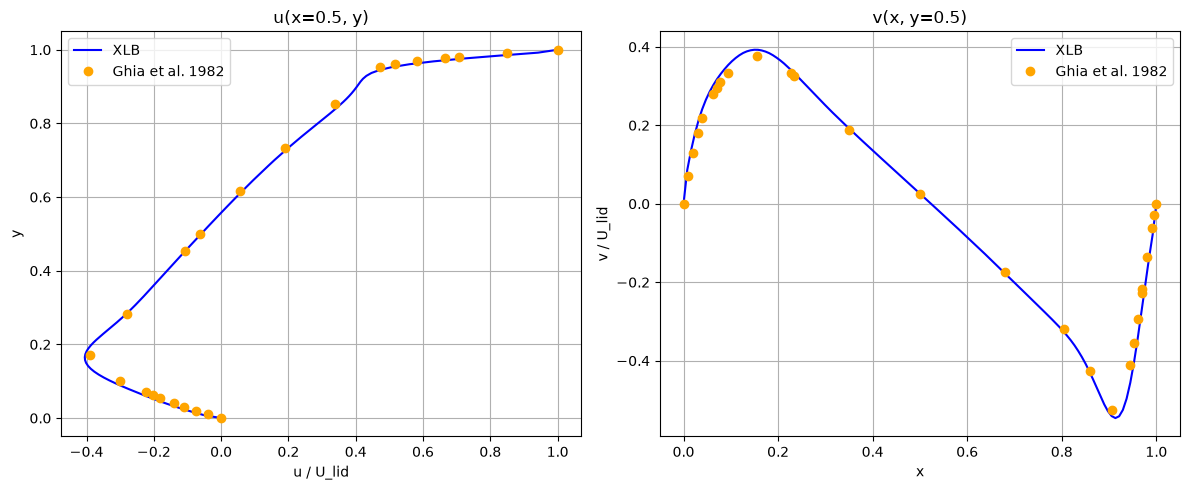

In [15]:
if ghia is not None:
    centerline_u = ghia["centerline_u"]  # u(x=0.5, y)
    centerline_v = ghia["centerline_v"]  # v(x, y=0.5)

    x_mid_idx = np.argmin(np.abs(x[1:-1] - 0.5))
    y_mid_idx = np.argmin(np.abs(y[1:-1] - 0.5))

    computed_u_centerline = np.concatenate([[0], ux[x_mid_idx, :], [prescribed_vel]])
    computed_v_centerline = np.concatenate([[0], uy[:, y_mid_idx], [0]])

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    axs[0].plot(computed_u_centerline / prescribed_vel, y, label="XLB", color="blue")
    axs[0].plot(np.array(centerline_u["u"]), centerline_u["y"], "o", label="Ghia et al. 1982", color="orange")
    axs[0].set_xlabel("u / U_lid")
    axs[0].set_ylabel("y")
    axs[0].set_title("u(x=0.5, y)")
    axs[0].legend()
    axs[0].grid()

    axs[1].plot(x, computed_v_centerline / prescribed_vel, label="XLB", color="blue")
    axs[1].plot(centerline_v["x"], np.array(centerline_v["v"]), "o", label="Ghia et al. 1982", color="orange")
    axs[1].set_xlabel("x")
    axs[1].set_ylabel("v / U_lid")
    axs[1].set_title("v(x, y=0.5)")
    axs[1].legend()
    axs[1].grid()

    fig.tight_layout()